In [5]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('../')
from conformalHDC.models import *
from conformalHDC.methods import *
from conformalHDC.utils import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

def run_experiment(var, random_state):
    alpha = 0.05
    
    # Initialize sampler
    sampler = NormalClusters(2, 2)
    
    # Define means and covariances
    mean1 = [2, 2]
    cov1 = [[0.1, 0], [0, 0.1]]  # Small variance

    mean2 = [6, 6]
    cov2 = [[var, 0], [0, var]]  # High variance

    # Sample data
    X, Y = sampler.sample(means=[mean1, mean2], covs=[cov1, cov2], sizes=[500, 5000])

    # Split the data into training and test sets
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=random_state)

    # Initialize the conformal predictor with the training data
    conformal = ConformalHDC(X_train, Y_train, random_state=random_state)

    # Make predictions on the test set
    pred = conformal.predict(X_test)
    pred = np.array(pred).reshape(-1, 1)

    # Generate conformal prediction sets
    pset = conformal.conformalPS(X_test, alpha, allow_empty=True)

    # Evaluate the conformal prediction sets (conformal method)
    df_m_pset = eval_m_psets(pset, Y_test)
    df_m_pset['method'] = 'conformalHDC'

    df_lc_pset = eval_lc_psets(pset, Y_test)
    df_lc_pset['method'] = 'conformalHDC'

    # Evaluate the predictions (hdc method)
    df_m_pred = eval_m_psets(pred, Y_test)
    df_m_pred['method'] = 'HDC'

    df_lc_pred = eval_lc_psets(pred, Y_test)
    df_lc_pred['method'] = 'HDC'

    # Add columns for var and random_state to each DataFrame
    df_m_pset['var'] = var
    df_m_pset['random_state'] = random_state
    df_lc_pset['var'] = var
    df_lc_pset['random_state'] = random_state

    df_m_pred['var'] = var
    df_m_pred['random_state'] = random_state
    df_lc_pred['var'] = var
    df_lc_pred['random_state'] = random_state

    # Concatenate results for this run
    result_m = pd.concat([df_m_pset, df_m_pred], ignore_index=True)
    result_lc = pd.concat([df_lc_pset, df_lc_pred], ignore_index=True)

    return result_m, result_lc

# Initialize empty lists to store results
all_results_m = []
all_results_lc = []

# Loop to run 50 repetitions with different random seeds
for i in tqdm(range(300)):
    random_state = i  # Set the random state for each run
    var_list = np.arange(4, 5.1, 0.2)  # Define the var_list
    for var in var_list:
        # Run the experiment
        result_m, result_lc = run_experiment(var, random_state)
        
        # Append the results to the list
        all_results_m.append(result_m)
        all_results_lc.append(result_lc)

# Concatenate all the results from all repetitions and variance settings
final_m_df = pd.concat(all_results_m, ignore_index=True)
final_lc_df = pd.concat(all_results_lc, ignore_index=True)

100%|████████████████████████████████████████████████████████████████████████████████| 300/300 [01:04<00:00,  4.66it/s]


In [13]:
final_m_df

,M-coverage,M-size,M-size|cov,method,var,random_state
0,0.936364,0.945455,1.000000,conformalHDC,4.0,0
1,0.910909,1.000000,1.000000,HDC,4.0,0
2,0.934545,0.936364,1.000000,conformalHDC,4.2,0
3,0.920000,1.000000,1.000000,HDC,4.2,0
4,0.934545,0.941818,1.001946,conformalHDC,4.4,0
...,...,...,...,...,...,...
3595,0.921818,1.000000,1.000000,HDC,4.6,299
3596,0.950909,0.963636,1.011472,conformalHDC,4.8,299
3597,0.918182,1.000000,1.000000,HDC,4.8,299
3598,0.958182,1.034545,1.077799,conformalHDC,5.0,299


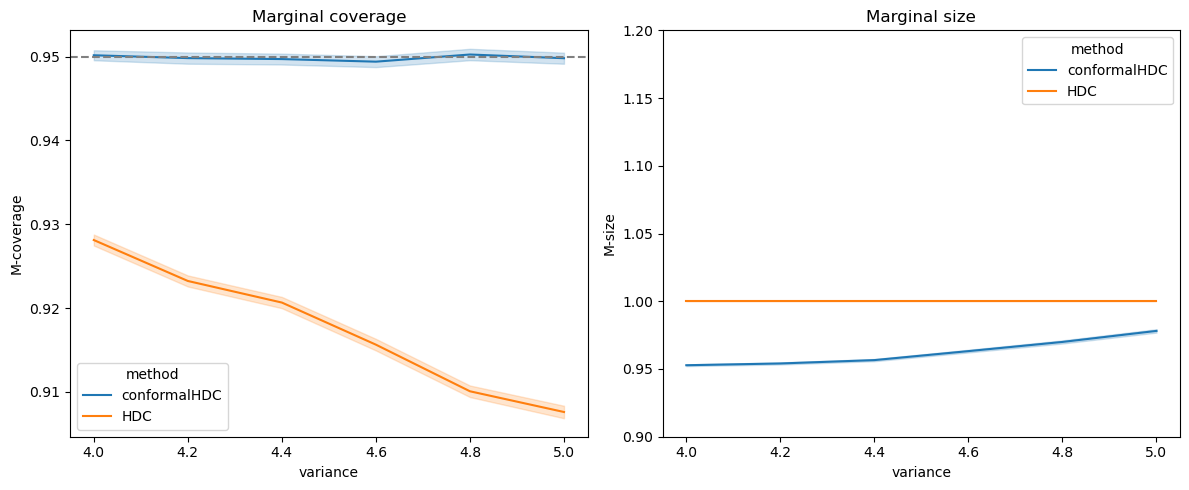

In [14]:
import seaborn as sns
# Set up the figure size
plt.figure(figsize=(12, 5))

# Plot 1: M-coverage vs var (aggregated over random_state)
plt.subplot(1, 2, 1)
sns.lineplot(x='var', y='M-coverage', hue='method', data=final_m_df, errorbar='se')
plt.axhline(0.95, color='gray', linestyle='--', label='nominal level')  # Add horizontal line at 0.95
plt.title('Marginal coverage')
plt.xlabel('variance')
plt.ylabel('M-coverage')

# Plot 2: M-size vs var (aggregated over random_state)
plt.subplot(1, 2, 2)
plt.ylim(0.9, 1.2)  # Set y-axis limit for M-size plot
sns.lineplot(x='var', y='M-size', hue='method', data=final_m_df, errorbar='se')
plt.title('Marginal size')
plt.xlabel('variance')
plt.ylabel('M-size')

# Adjust layout for clear display
plt.tight_layout()

plt.savefig(r'G:\My Drive\Research\ConformalHD\presentation\marginal_comp.png', dpi=300, bbox_inches='tight')

# Show the plots
plt.show()

In [15]:
final_lc_df

,class0-LC-coverage,class0-LC-size,class0-LC-size|cov,class1-LC-coverage,class1-LC-size,class1-LC-size|cov,method,var,random_state
0,0.937500,0.937500,1.000000,0.936255,0.946215,1.000000,conformalHDC,4.0,0
1,1.000000,1.000000,1.000000,0.902390,1.000000,1.000000,HDC,4.0,0
2,0.979167,0.979167,1.000000,0.930279,0.932271,1.000000,conformalHDC,4.2,0
3,1.000000,1.000000,1.000000,0.912351,1.000000,1.000000,HDC,4.2,0
4,0.958333,1.000000,1.000000,0.932271,0.936255,1.002137,conformalHDC,4.4,0
...,...,...,...,...,...,...,...,...,...
3595,1.000000,1.000000,1.000000,0.913306,1.000000,1.000000,HDC,4.6,299
3596,0.925926,1.055556,1.120000,0.953629,0.953629,1.000000,conformalHDC,4.8,299
3597,1.000000,1.000000,1.000000,0.909274,1.000000,1.000000,HDC,4.8,299
3598,0.944444,1.666667,1.764706,0.959677,0.965726,1.004202,conformalHDC,5.0,299


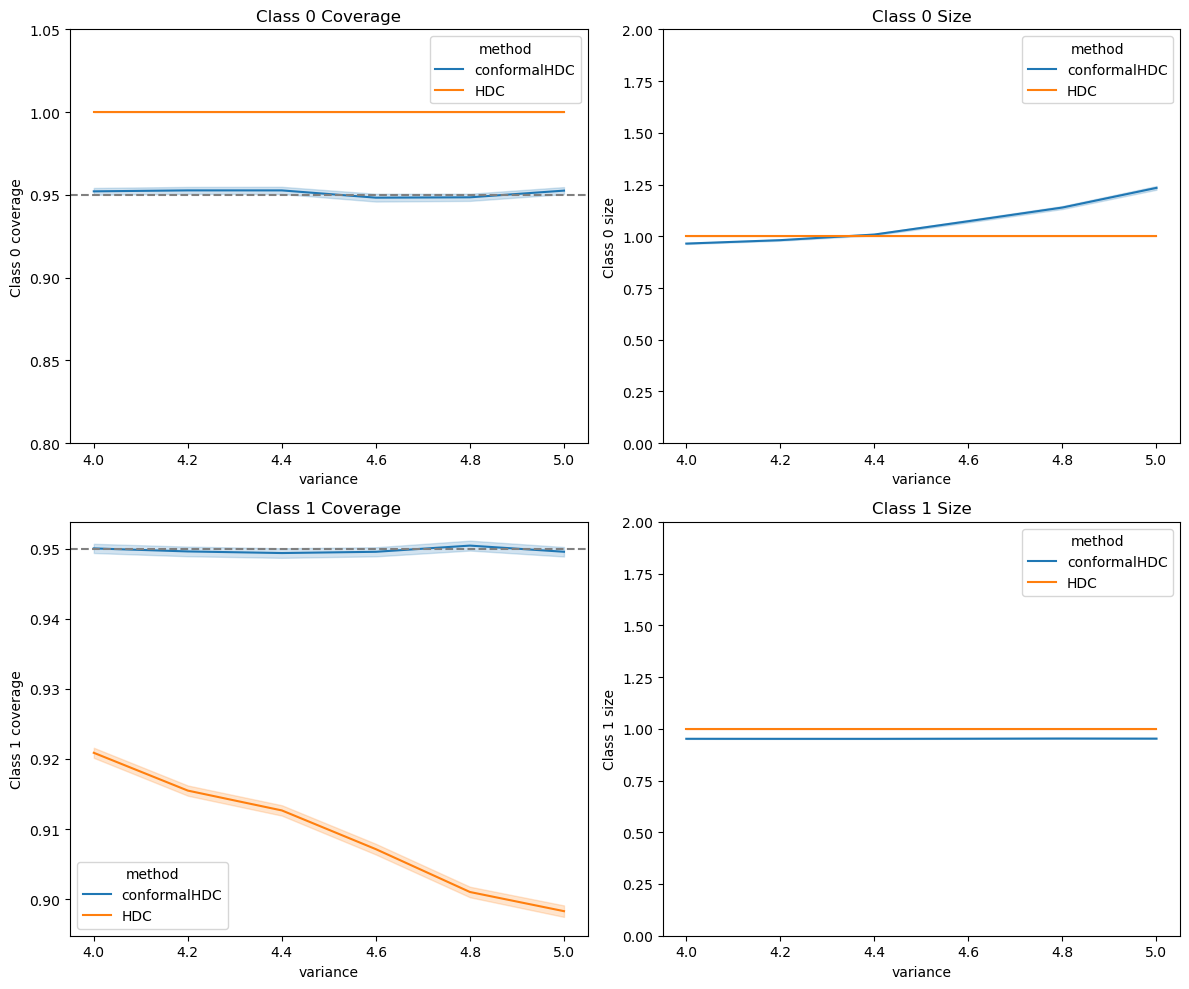

In [17]:
# Set up the figure size
plt.figure(figsize=(12, 10))

# Plot for Class 0
plt.subplot(2, 2, 1)
sns.lineplot(x='var', y='class0-LC-coverage', hue='method', data=final_lc_df, errorbar='se')
plt.ylim(0.8, 1.05)  # Adjust the y-axis limit as needed
plt.axhline(0.95, color='gray', linestyle='--', label='0.95 Threshold')
plt.title('Class 0 Coverage')
plt.xlabel('variance')
plt.ylabel('Class 0 coverage')

plt.subplot(2, 2, 2)
sns.lineplot(x='var', y='class0-LC-size', hue='method', data=final_lc_df, errorbar='se')
plt.ylim(0, 2)  # Adjust the y-axis limit as needed
plt.title('Class 0 Size')
plt.xlabel('variance')
plt.ylabel('Class 0 size')

# Plot for Class 1
plt.subplot(2, 2, 3)
sns.lineplot(x='var', y='class1-LC-coverage', hue='method', data=final_lc_df, errorbar='se')
plt.axhline(0.95, color='gray', linestyle='--', label='0.95 Threshold')
plt.title('Class 1 Coverage')
plt.xlabel('variance')
plt.ylabel('Class 1 coverage')

plt.subplot(2, 2, 4)
sns.lineplot(x='var', y='class1-LC-size', hue='method', data=final_lc_df, errorbar='se')
plt.ylim(0, 2)  # Adjust the y-axis limit as needed
plt.title('Class 1 Size')
plt.xlabel('variance')
plt.ylabel('Class 1 size')

# Adjust layout for clear display
plt.tight_layout()

# Save the plot to a file before displaying
plt.savefig(r'G:\My Drive\Research\ConformalHD\presentation\lc_comp.png', dpi=300, bbox_inches='tight')

# Show the plots
plt.show()


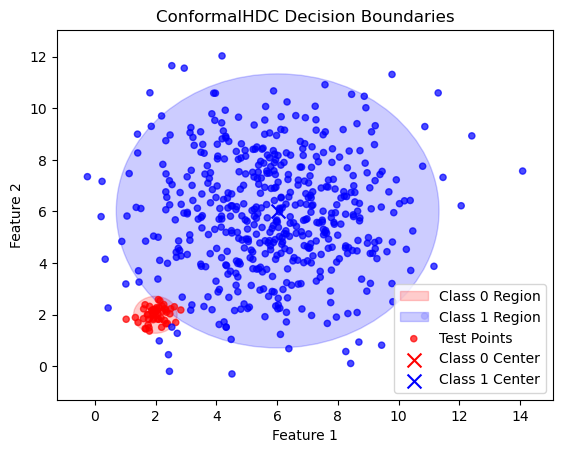

In [1076]:
plt = conformal.plot_conformal_boundary(X_test, Y_test)

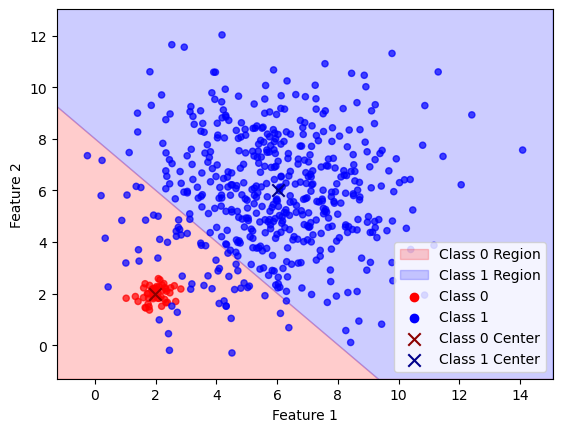

<module 'matplotlib.pyplot' from 'C:\\Users\\liang\\anaconda3\\envs\\conformalHDC\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [1077]:
conformal.plot_HDC_boundary(X_test, Y_test)

In [1126]:
x_min, x_max =np.min(X_train[:, 0]), np.max(X_train[:, 0])
y_min, y_max =np.min(X_train[:, 1]), np.max(X_train[:, 1])-1.5


inputs_test=X_test
labels_test=Y_test
alpha_test_point=0.2
alpha_region=0.1

test_point=np.array([2.3,4])

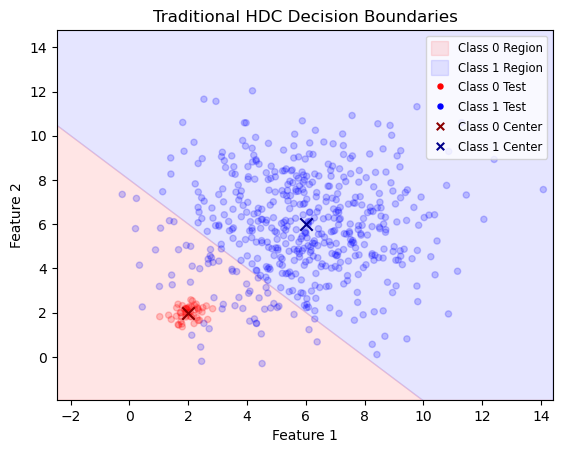

In [1129]:
# if xlim is None:
#     x_min, x_max = np.min(inputs_test[:, 0])-1, np.max(inputs_test[:, 0])+1
# else:
#     x_min, x_max = xlim[0], xlim[1]

# if ylim is None:
#     y_min, y_max = np.min(inputs_test[:, 1])-1, np.max(inputs_test[:, 1])+1
# else:
#     y_min, y_max = ylim[0], ylim[1]

midpoint = (conformal.classHVs[0] + conformal.classHVs[1]) / 2
slope = (conformal.classHVs[1][1] - conformal.classHVs[0][1]) / (conformal.classHVs[1][0] - conformal.classHVs[0][0])
perp_slope = -1 / slope

# Equation of the perpendicular bisector: y = perp_slope * (x - midpoint_x) + midpoint_y
x_vals = np.linspace(x_min, x_max, 100)
y_vals = perp_slope * (x_vals - midpoint[0]) + midpoint[1]

# Create the plot
plt.figure()

# HDC Boundary
plt.fill_between(x_vals, y_vals, y_min, color='red', alpha=alpha_region, label='Class 0 Region')
plt.fill_between(x_vals, y_vals, y_max, color='blue', alpha=alpha_region, label='Class 1 Region')

plt.scatter([], [], color='red', label='Class 0 Test')  # Empty scatter to add red color to the legend
plt.scatter([], [], color='blue', label='Class 1 Test')  # Empty scatter to add blue color to the legend

# Scatter plot of the test points
colors = ['red' if c == 0 else 'blue' for c in labels_test]
plt.scatter(inputs_test[:, 0], inputs_test[:, 1], c=colors,  s=20, alpha=alpha_test_point)

#plt.scatter(test_point[0], test_point[1], c='green',  s=30, alpha=0.8, label='Test point')

# Scatter plot of the class centers
plt.scatter(conformal.classHVs[0][0], conformal.classHVs[0][1], color='darkred', marker='x', s=80, label='Class 0 Center')
plt.scatter(conformal.classHVs[1][0], conformal.classHVs[1][1], color='darkblue', marker='x', s=80, label='Class 1 Center')

# Add labels and other settings
plt.xlim([x_min, x_max])
plt.ylim([y_min, y_max])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Traditional HDC Decision Boundaries')
plt.legend(fontsize='small', markerscale=0.6, handlelength=1.5, handleheight=1.5, loc='upper right')


#plt.savefig(r'G:\My Drive\Research\ConformalHD\presentation\clusters_train.png')
#plt.savefig(r'G:\My Drive\Research\ConformalHD\presentation\clusters_train_center.png')
#plt.savefig(r'G:\My Drive\Research\ConformalHD\presentation\clusters_test.png')
plt.savefig(r'G:\My Drive\Research\ConformalHD\presentation\hdc_test_boundary.png')

plt.show()

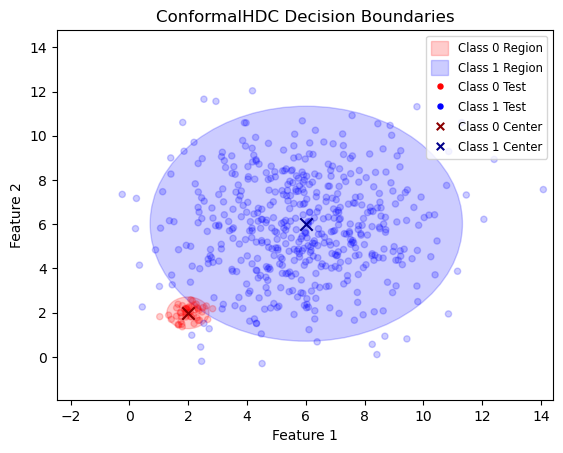

In [1131]:
# Conformal boundary

# Create the plot
fig, ax = plt.subplots()

# Plot decision boundaries as circles
circle1 = plt.Circle(conformal.classHVs[0], conformal.quantiles[0], color='r', alpha=0.2, fill=True, label='Class 0 Region')
circle2 = plt.Circle(conformal.classHVs[1], conformal.quantiles[1], color='b', alpha=0.2, fill=True, label='Class 1 Region')

ax.add_artist(circle1)
ax.add_artist(circle2)

# Scatter plot of the test points
ax.scatter([], [], color='red', label='Class 0 Test')  # Empty scatter to add red color to the legend
ax.scatter([], [], color='blue', label='Class 1 Test')  # Empty scatter to add blue color to the legend

# Scatter plot of the test points
colors = ['red' if c == 0 else 'blue' for c in labels_test]
ax.scatter(inputs_test[:, 0], inputs_test[:, 1], c=colors,  s=20, alpha=alpha_test_point)

# Scatter plot of the class centers
ax.scatter(conformal.classHVs[0][0], conformal.classHVs[0][1], color='darkred', marker='x', s=80, label='Class 0 Center')
ax.scatter(conformal.classHVs[1][0], conformal.classHVs[1][1], color='darkblue', marker='x', s=80, label='Class 1 Center')

# Labels and legend
plt.xlim([x_min, x_max])
plt.ylim([y_min, y_max])
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('ConformalHDC Decision Boundaries')
ax.legend(fontsize='small', markerscale=0.6, handlelength=1.5, handleheight=1.5, loc='upper right')
plt.savefig(r'G:\My Drive\Research\ConformalHD\presentation\conformal_test_boundary.png')



0.05